<a href="https://colab.research.google.com/github/Nois12/AIFFEL_quest_rs/blob/main/GoingDeeper/Gd07/Mini_Bert_Pretrain.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mini BERT 만들기



## Flow


```
데이터 다운로드 (kowiki.txt)
        │
공통 설정 (시드 고정, device)
        │
하이퍼파라미터 CONFIG 정리
        │
Tokenizer 학습 (SentencePiece, vocab_size=8000)
        │
데이터 전처리 함수 정의
   ├─ create_pretrain_mask()        : MLM 마스킹 (80% [MASK] / 10% 랜덤 / 10% 원본)
   ├─ trim_tokens()                 : 두 문장 길이를 max_seq에 맞게 자름
   ├─ create_pretrain_instances()   : NSP pair 생성 + 위 마스킹 결합 → 1개 instance
   └─ make_pretrain_data()          : 코퍼스 전체 순회 → json lines로 저장
        │
   (전체 코퍼스에 대해 make_pretrain_data 실행)
        │
데이터 로딩 + train/val split
   ├─ load_pretrain_data()          : np.memmap으로 json → 배열 로딩
   └─ build_train_val_datasets()    : 시드 고정 랜덤 분할 → train/val TensorDataset
        │
BERT 모델 구현
   Embedding(Token+Position+Segment) → EncoderLayer × n_layer → [CLS]:NSP head / 전체:MLM head
        │
   (모델 생성 + count_parameters로 파라미터 수 확인, 목표 ≈1M)
        │
Loss / Accuracy / LR 스케줄 정의
   ├─ loss_fn_nsp, loss_fn_mlm (CrossEntropyLoss)
   ├─ compute_accuracy()
   └─ CosineSchedule (warmup → cosine decay)
        │
학습 루프 (train_model)
   매 epoch: train_dataloader로 학습 → val_dataloader로 검증 → best 모델 저장
   (기본 10 epoch)
        │
train/val loss·accuracy 시각화 (plot_history)
        │
비교실험 (ablation)
   ├─ compare_vocab_size()   : 4000 / 8000 / 16000
   ├─ compare_model_size()   : small / base(~1M) / large
   └─ compare_mask_prob()    : 0.10 / 0.15 / 0.20
   → 공통으로 plot_comparison()을 이용해 그래프로 비교
```


## 데이터 다운로드 / 글씨 설정



In [1]:
%%bash
mkdir -p ./data ./models
if [ ! -f ./data/kowiki.txt ]; then
    wget -q https://d3s0tskafalll9.cloudfront.net/media/documents/kowiki.txt.zip -O ./data/kowiki.txt.zip
    unzip -o ./data/kowiki.txt.zip -d ./data
fi
pip install -q sentencepiece tqdm

Archive:  ./data/kowiki.txt.zip
  inflating: ./data/kowiki.txt       


In [2]:
try:
    import matplotlib
    import matplotlib.pyplot as plt
    import matplotlib.font_manager as fm
    from pathlib import Path
    !apt-get -qq -y install fonts-nanum > /dev/null 2>&1
    font_path = Path('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
    if font_path.exists():
        fm.fontManager.addfont(str(font_path))
        plt.rcParams['font.family'] = 'NanumGothic'
        matplotlib.rcParams['axes.unicode_minus'] = False
except Exception as e:
    print('[폰트 설정 생략]', e)

## 라이브러리 불러오기 / 공통 유틸


In [3]:
import os
import json
import math
import random

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

import sentencepiece as spm
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

SEED = 1234

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device, "| torch:", torch.__version__)

device: cuda | torch: 2.11.0+cu128


## 하이퍼파라미터 정리



In [4]:
CONFIG = {
    # 경로
    "data_dir": "./data",
    "model_dir": "./models",
    "corpus_file": "./data/kowiki.txt",
    "vocab_prefix": "./models/ko_8000",
    "pretrain_json_path": "./data/bert_pretrain.json",

    # 데이터
    "vocab_size": 8000,
    "n_seq": 128,
    "mask_prob": 0.15,
    "val_ratio": 0.05,
    "num_train_samples": None,

    # 모델 (전체 파라미터 ≈ 1M)
    "d_model": 96,
    "n_head": 4,
    "d_head": 24,
    "d_ff": 384,
    "n_layer": 2,
    "dropout": 0.1,
    "layernorm_epsilon": 1e-3,

    # 학습
    "batch_size": 64,
    "epochs": 10,
    "max_lr": 2.5e-4,
    "warmup_ratio": 0.1,
    "mlm_loss_weight": 1.0,
}

os.makedirs(CONFIG["data_dir"], exist_ok=True)
os.makedirs(CONFIG["model_dir"], exist_ok=True)
CONFIG

{'data_dir': './data',
 'model_dir': './models',
 'corpus_file': './data/kowiki.txt',
 'vocab_prefix': './models/ko_8000',
 'pretrain_json_path': './data/bert_pretrain.json',
 'vocab_size': 8000,
 'n_seq': 128,
 'mask_prob': 0.15,
 'val_ratio': 0.05,
 'num_train_samples': None,
 'd_model': 96,
 'n_head': 4,
 'd_head': 24,
 'd_ff': 384,
 'n_layer': 2,
 'dropout': 0.1,
 'layernorm_epsilon': 0.001,
 'batch_size': 64,
 'epochs': 10,
 'max_lr': 0.00025,
 'warmup_ratio': 0.1,
 'mlm_loss_weight': 1.0}

## Tokenizer 준비 (SentencePiece, vocab_size=8000)


In [5]:
def train_sentencepiece(corpus_file, prefix, vocab_size):

    spm.SentencePieceTrainer.train(
        f"--input={corpus_file} "
        f"--model_prefix={prefix} "
        f"--vocab_size={vocab_size + 7} "
        f"--model_type=bpe --max_sentence_length=999999 "
        f"--pad_id=0 --pad_piece=[PAD] "
        f"--unk_id=1 --unk_piece=[UNK] "
        f"--bos_id=2 --bos_piece=[BOS] "
        f"--eos_id=3 --eos_piece=[EOS] "
        f"--user_defined_symbols=[SEP],[CLS],[MASK]"
    )


def load_vocab(prefix):
    v = spm.SentencePieceProcessor()
    v.load(prefix + ".model")
    vocab_list = [v.id_to_piece(i) for i in range(7, len(v)) if not v.is_unknown(i)]
    return v, vocab_list

# 이미 학습된 모델이 없으면 학습
if not os.path.exists(CONFIG["vocab_prefix"] + ".model"):
    train_sentencepiece(CONFIG["corpus_file"], CONFIG["vocab_prefix"], CONFIG["vocab_size"])

vocab, VOCAB_LIST = load_vocab(CONFIG["vocab_prefix"])
len(vocab), len(VOCAB_LIST)

(8007, 8000)

## 데이터 전처리 함수

 ① MASK 생성 → ② NSP pair 생성 → ③ 둘을 합쳐 pretrain instance 생성 → ④ 전체 코퍼스를 돌면서 json으로 저장

In [6]:
def create_pretrain_mask(tokens, mask_cnt, vocab_list):
    """
    MLM용 마스킹. 띄어쓰기(subword) 단위로 묶어서 마스킹하며,
    마스킹 대상의 80%는 [MASK], 10%는 랜덤 토큰, 10%는 원래 토큰을 그대로 둔다.
    :return tokens: 마스킹이 적용된 토큰 리스트
    :return mask_idx: 마스킹된 위치
    :return mask_label: 마스킹되기 전 원래 토큰(정답)
    """
    cand_idx = []
    for i, token in enumerate(tokens):
        if token in ("[CLS]", "[SEP]"):
            continue
        if cand_idx and not token.startswith(u"\u2581"):
            cand_idx[-1].append(i)
        else:
            cand_idx.append([i])

    random.shuffle(cand_idx)

    mask_lms = []
    for index_set in cand_idx:
        if len(mask_lms) >= mask_cnt:
            break
        if len(mask_lms) + len(index_set) > mask_cnt:
            continue
        dice = random.random()
        for index in index_set:
            if dice < 0.8:
                masked_token = "[MASK]"
            elif dice < 0.9:
                masked_token = tokens[index]
            else:
                masked_token = random.choice(vocab_list)
            mask_lms.append({"index": index, "label": tokens[index]})
            tokens[index] = masked_token

    mask_lms = sorted(mask_lms, key=lambda x: x["index"])
    mask_idx = [p["index"] for p in mask_lms]
    mask_label = [p["label"] for p in mask_lms]
    return tokens, mask_idx, mask_label


def trim_tokens(tokens_a, tokens_b, max_seq):

    while len(tokens_a) + len(tokens_b) > max_seq:
        if len(tokens_a) > len(tokens_b):
            del tokens_a[0]
        else:
            tokens_b.pop()


def create_pretrain_instances(doc, n_seq, mask_prob, vocab_list):

    max_seq = n_seq - 3

    instances = []
    current_chunk = []
    current_length = 0
    for i in range(len(doc)):
        current_chunk.append(doc[i])
        current_length += len(doc[i])

        is_last = (i == len(doc) - 1)
        if len(current_chunk) > 1 and (is_last or current_length >= max_seq):
            a_end = random.randrange(1, len(current_chunk)) if len(current_chunk) > 1 else 1
            tokens_a = [t for j in range(a_end) for t in current_chunk[j]]
            tokens_b = [t for j in range(a_end, len(current_chunk)) for t in current_chunk[j]]

            if random.random() < 0.5:
                is_next = 0
                tokens_a, tokens_b = tokens_b, tokens_a
            else:
                is_next = 1

            trim_tokens(tokens_a, tokens_b, max_seq)
            assert len(tokens_a) > 0 and len(tokens_b) > 0

            tokens = ["[CLS]"] + tokens_a + ["[SEP]"] + tokens_b + ["[SEP]"]
            segment = [0] * (len(tokens_a) + 2) + [1] * (len(tokens_b) + 1)
            tokens, mask_idx, mask_label = create_pretrain_mask(
                tokens, int((len(tokens) - 3) * mask_prob), vocab_list
            )

            instances.append({
                "tokens": tokens,
                "segment": segment,
                "is_next": is_next,
                "mask_idx": mask_idx,
                "mask_label": mask_label,
            })

            current_chunk = []
            current_length = 0
    return instances


def make_pretrain_data(vocab, vocab_list, in_file, out_file, n_seq, mask_prob=0.15):

    with open(in_file, "r") as in_f:
        line_cnt = sum(1 for _ in in_f)

    with open(in_file, "r") as in_f, open(out_file, "w") as out_f:
        doc = []
        for line in tqdm(in_f, total=line_cnt, desc=f"make_pretrain_data({os.path.basename(out_file)})"):
            line = line.strip()
            if line == "":
                if doc:
                    for instance in create_pretrain_instances(doc, n_seq, mask_prob, vocab_list):
                        out_f.write(json.dumps(instance, ensure_ascii=False) + "\n")
                    doc = []
            else:
                pieces = vocab.encode_as_pieces(line)
                if pieces:
                    doc.append(pieces)
        if doc:
            for instance in create_pretrain_instances(doc, n_seq, mask_prob, vocab_list):
                out_f.write(json.dumps(instance, ensure_ascii=False) + "\n")

### pretrain 데이터 생성 실행

이미 만든 json이 있으면 건너뛰게 했다.


In [7]:
if not os.path.exists(CONFIG["pretrain_json_path"]):
    make_pretrain_data(
        vocab, VOCAB_LIST,
        CONFIG["corpus_file"], CONFIG["pretrain_json_path"],
        CONFIG["n_seq"], CONFIG["mask_prob"],
    )

make_pretrain_data(bert_pretrain.json):   0%|          | 0/3957761 [00:00<?, ?it/s]

## 데이터 로딩 + train/val split


In [8]:
def load_pretrain_data(vocab, filename, n_seq, count=None, tag="data"):
    """
    전처리된 json lines 파일을 np.memmap 배열로 로딩했다.
    :param count: 로딩할 데이터 수 (None이면 전체)
    :param tag: memmap 파일 이름 충돌 방지용 태그 (비교실험에서 여러 데이터셋을 동시에 다룰 때 사용)
    """
    with open(filename, "r") as f:
        total = sum(1 for _ in f)
    if count is not None:
        total = min(total, count)

    enc_tokens = np.memmap(f"{CONFIG['data_dir']}/{tag}_enc_tokens.memmap", mode="w+", dtype=np.int32, shape=(total, n_seq))
    segments   = np.memmap(f"{CONFIG['data_dir']}/{tag}_segments.memmap",   mode="w+", dtype=np.int32, shape=(total, n_seq))
    labels_nsp = np.memmap(f"{CONFIG['data_dir']}/{tag}_labels_nsp.memmap", mode="w+", dtype=np.int32, shape=(total,))
    labels_mlm = np.memmap(f"{CONFIG['data_dir']}/{tag}_labels_mlm.memmap", mode="w+", dtype=np.int32, shape=(total, n_seq))

    with open(filename, "r") as f:
        for i, line in enumerate(tqdm(f, total=total, desc=f"load_pretrain_data({tag})")):
            if i >= total:
                break
            data = json.loads(line)

            enc_token = [vocab.piece_to_id(p) for p in data["tokens"]]
            enc_token += [0] * (n_seq - len(enc_token))

            segment = data["segment"] + [0] * (n_seq - len(data["segment"]))

            mask_idx = np.array(data["mask_idx"], dtype=np.int32)
            mask_label = np.array([vocab.piece_to_id(p) for p in data["mask_label"]], dtype=np.int32)
            label_mlm = np.zeros(n_seq, dtype=np.int32)
            if len(mask_idx) > 0:
                label_mlm[mask_idx] = mask_label

            enc_tokens[i] = enc_token
            segments[i] = segment
            labels_nsp[i] = data["is_next"]
            labels_mlm[i] = label_mlm

    return (enc_tokens, segments), (labels_nsp, labels_mlm)


def to_tensor(arr, idx):
    return torch.tensor(np.array(arr[idx]), dtype=torch.long)


def build_train_val_datasets(vocab, json_path, n_seq, val_ratio, count=None, tag="data"):

    (enc_tokens, segments), (labels_nsp, labels_mlm) = load_pretrain_data(
        vocab, json_path, n_seq, count=count, tag=tag
    )

    n_total = len(enc_tokens)
    n_val = max(1, int(n_total * val_ratio))
    rng = np.random.RandomState(SEED)
    perm = rng.permutation(n_total)
    val_idx, train_idx = perm[:n_val], perm[n_val:]

    train_dataset = TensorDataset(
        to_tensor(enc_tokens, train_idx), to_tensor(segments, train_idx),
        to_tensor(labels_nsp, train_idx), to_tensor(labels_mlm, train_idx),
    )
    val_dataset = TensorDataset(
        to_tensor(enc_tokens, val_idx), to_tensor(segments, val_idx),
        to_tensor(labels_nsp, val_idx), to_tensor(labels_mlm, val_idx),
    )
    return train_dataset, val_dataset


train_dataset, val_dataset = build_train_val_datasets(
    vocab, CONFIG["pretrain_json_path"], CONFIG["n_seq"], CONFIG["val_ratio"],
    count=CONFIG["num_train_samples"], tag="main",
)

train_dataloader = DataLoader(train_dataset, batch_size=CONFIG["batch_size"], shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=CONFIG["batch_size"], shuffle=False)

print(f"train={len(train_dataset)}, val={len(val_dataset)}")


load_pretrain_data(main):   0%|          | 0/918173 [00:00<?, ?it/s]

train=872265, val=45908


## BERT 모델 구현



In [9]:
def get_pad_mask(tokens, i_pad=0):

    return (tokens == i_pad).float().unsqueeze(1)


def get_ahead_mask(tokens, i_pad=0):

    n_seq = tokens.size(1)
    ahead_mask = 1 - torch.tril(torch.ones((n_seq, n_seq), device=tokens.device))
    ahead_mask = ahead_mask.unsqueeze(0)
    pad_mask = get_pad_mask(tokens, i_pad)
    return torch.maximum(ahead_mask, pad_mask)


def gelu(x):

    return 0.5 * x * (1 + torch.tanh(math.sqrt(2 / math.pi) * (x + 0.044715 * torch.pow(x, 3))))


def kernel_initializer(stddev=0.02):

    def _init(tensor):
        return torch.nn.init.trunc_normal_(tensor, std=stddev)
    return _init


def bias_initializer():

    return torch.nn.init.zeros_


class Config(dict):

    __getattr__ = dict.__getitem__
    __setattr__ = dict.__setitem__

    @classmethod
    def load(cls, file):
        with open(file, "r") as f:
            return cls(json.loads(f.read()))

    def save(self, file):
        with open(file, "w") as f:
            f.write(json.dumps(self, ensure_ascii=False, indent=2))


class SharedEmbedding(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.n_vocab = config.n_vocab
        self.d_model = config.d_model
        self.shared_weights = nn.Parameter(torch.empty(self.n_vocab, self.d_model))
        kernel_initializer()(self.shared_weights)

    def forward(self, inputs, mode="embedding"):
        if mode == "embedding":
            return self.shared_weights[inputs.long()]
        elif mode == "linear":
            n_batch, n_seq, _ = inputs.shape
            outputs = torch.matmul(inputs.view(-1, self.d_model), self.shared_weights.T)
            return outputs.view(n_batch, n_seq, self.n_vocab)
        raise ValueError(f"mode {mode} is not valid.")


class PositionEmbedding(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.embedding = nn.Embedding(config.n_seq, config.d_model)
        kernel_initializer()(self.embedding.weight)

    def forward(self, inputs):
        position = torch.arange(inputs.size(1), device=inputs.device).unsqueeze(0)
        return self.embedding(position)


class ScaleDotProductAttention(nn.Module):
    def forward(self, Q, K, V, attn_mask):
        scale = math.sqrt(K.shape[-1])
        attn_score = torch.matmul(Q, K.transpose(-2, -1)) / scale
        attn_score = attn_score - (attn_mask * 1e9)
        attn_prob = F.softmax(attn_score, dim=-1)
        return torch.matmul(attn_prob, V)


class MultiHeadAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.n_head = config.n_head
        self.d_head = config.d_head
        proj_dim = config.n_head * config.d_head

        self.W_Q = nn.Linear(config.d_model, proj_dim)
        self.W_K = nn.Linear(config.d_model, proj_dim)
        self.W_V = nn.Linear(config.d_model, proj_dim)
        self.attention = ScaleDotProductAttention()
        self.W_O = nn.Linear(proj_dim, config.d_model)

    def forward(self, Q, K, V, attn_mask):
        batch_size = Q.shape[0]

        def split_heads(x):
            return x.view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)

        attn_out = self.attention(split_heads(self.W_Q(Q)), split_heads(self.W_K(K)),
                                   split_heads(self.W_V(V)), attn_mask.unsqueeze(1))
        attn_out = attn_out.transpose(1, 2).contiguous().view(batch_size, -1, self.n_head * self.d_head)
        return self.W_O(attn_out)


class PositionWiseFeedForward(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.W_1 = nn.Linear(config.d_model, config.d_ff)
        self.W_2 = nn.Linear(config.d_ff, config.d_model)

    def forward(self, inputs):
        return self.W_2(gelu(self.W_1(inputs)))


class EncoderLayer(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.self_attention = MultiHeadAttention(config)
        self.norm1 = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)
        self.ffn = PositionWiseFeedForward(config)
        self.norm2 = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, enc_embed, self_mask):
        attn_val = self.self_attention(enc_embed, enc_embed, enc_embed, self_mask)
        norm1_val = self.norm1(enc_embed + self.dropout(attn_val))
        ffn_val = self.ffn(norm1_val)
        return self.norm2(norm1_val + self.dropout(ffn_val))


class BERT(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.i_pad = config.i_pad
        self.embedding = SharedEmbedding(config)
        self.position = PositionEmbedding(config)
        self.segment = nn.Embedding(2, config.d_model)
        self.norm = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)
        self.encoder_layers = nn.ModuleList([EncoderLayer(config) for _ in range(config.n_layer)])
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, enc_tokens, segments):
        self_mask = get_pad_mask(enc_tokens, self.i_pad)
        enc_out = self.dropout(self.get_embedding(enc_tokens, segments))
        for layer in self.encoder_layers:
            enc_out = layer(enc_out, self_mask)
        logits_cls = enc_out[:, 0]
        logits_lm = self.embedding(enc_out, mode="linear")
        return logits_cls, logits_lm

    def get_embedding(self, tokens, segments):
        embed = self.embedding(tokens) + self.position(tokens) + self.segment(segments)
        return self.norm(embed)


class PooledOutput(nn.Module):
    def __init__(self, config, n_output):
        super().__init__()
        self.dense1 = nn.Linear(config.d_model, config.d_model)
        self.dense2 = nn.Linear(config.d_model, n_output, bias=False)

    def forward(self, inputs):
        return self.dense2(torch.tanh(self.dense1(inputs)))


class PreTrainModel(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.bert = BERT(config)
        self.pooled_output = PooledOutput(config, 2)

    def forward(self, enc_tokens, segments):
        logits_cls, logits_lm = self.bert(enc_tokens.long(), segments.long())
        outputs_nsp = self.pooled_output(logits_cls)
        return outputs_nsp, logits_lm


def build_model_config(vocab, config):

    return Config(
        n_vocab=len(vocab), i_pad=vocab.pad_id(), n_seq=config["n_seq"],
        d_model=config["d_model"], n_head=config["n_head"], d_head=config["d_head"],
        d_ff=config["d_ff"], n_layer=config["n_layer"],
        dropout=config["dropout"], layernorm_epsilon=config["layernorm_epsilon"],
    )


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

### 모델 생성 및 파라미터 수 확인 (목표: 1M)


In [10]:
model_config = build_model_config(vocab, CONFIG)
model_config.save(f"{CONFIG['model_dir']}/model_config.json")

# 저장한 json이 제대로 다시 불러와지는지 확인
reloaded_config = Config.load(f"{CONFIG['model_dir']}/model_config.json")
assert reloaded_config.d_model == model_config.d_model

model = PreTrainModel(model_config).to(device)
n_params = count_parameters(model)
print(f"총 파라미터 수: {n_params:,} ({n_params/1e6:.2f}M)")

총 파라미터 수: 1,014,528 (1.01M)


## Loss / Accuracy / Learning Rate 스케줄


In [11]:
loss_fn_nsp = nn.CrossEntropyLoss()
loss_fn_mlm = nn.CrossEntropyLoss(ignore_index=0)


def compute_accuracy(logits_nsp, labels_nsp, logits_mlm, labels_mlm):
    nsp_acc = (logits_nsp.argmax(dim=-1) == labels_nsp).float().mean()

    mlm_mask = (labels_mlm != 0)
    mlm_correct = (logits_mlm.argmax(dim=-1) == labels_mlm) & mlm_mask
    mlm_acc = mlm_correct.float().sum() / mlm_mask.float().sum().clamp(min=1)
    return nsp_acc.item(), mlm_acc.item()


class CosineSchedule:

    def __init__(self, train_steps, warmup_steps, max_lr):
        self.train_steps = train_steps
        self.warmup_steps = max(1, warmup_steps)
        self.max_lr = max_lr
        self.step_num = 0

    def get_lr(self):
        if self.step_num <= self.warmup_steps:
            return (self.step_num / self.warmup_steps) * self.max_lr
        progress = (self.step_num - self.warmup_steps) / max(1, self.train_steps - self.warmup_steps)
        return 0.5 * self.max_lr * (1 + math.cos(math.pi * progress))

    def step(self):
        self.step_num += 1
        return self.get_lr()

## 학습 루프 (train + validation)


In [12]:
def run_epoch(model, dataloader, optimizer=None, lr_scheduler=None, mlm_loss_weight=1.0):

    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    totals = {"loss": 0.0, "nsp_loss": 0.0, "mlm_loss": 0.0, "nsp_acc": 0.0, "mlm_acc": 0.0}

    with torch.set_grad_enabled(is_train):
        for enc_tokens_b, segments_b, labels_nsp_b, labels_mlm_b in dataloader:
            enc_tokens_b = enc_tokens_b.to(device)
            segments_b = segments_b.to(device)
            labels_nsp_b = labels_nsp_b.to(device)
            labels_mlm_b = labels_mlm_b.to(device)

            logits_nsp, logits_mlm = model(enc_tokens_b, segments_b)

            loss_nsp = loss_fn_nsp(logits_nsp, labels_nsp_b)
            loss_mlm = loss_fn_mlm(logits_mlm.view(-1, logits_mlm.size(-1)), labels_mlm_b.view(-1))
            loss = loss_nsp + mlm_loss_weight * loss_mlm

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                if lr_scheduler is not None:
                    lr = lr_scheduler.step()
                    for g in optimizer.param_groups:
                        g["lr"] = lr

            nsp_acc, mlm_acc = compute_accuracy(logits_nsp, labels_nsp_b, logits_mlm, labels_mlm_b)

            totals["loss"] += loss.item()
            totals["nsp_loss"] += loss_nsp.item()
            totals["mlm_loss"] += loss_mlm.item()
            totals["nsp_acc"] += nsp_acc
            totals["mlm_acc"] += mlm_acc

    n_batches = len(dataloader)
    return {k: v / n_batches for k, v in totals.items()}


def train_model(model, train_dataloader, val_dataloader, config, verbose=True, checkpoint_tag=None):

    set_seed(SEED)
    suffix = f"_{checkpoint_tag}" if checkpoint_tag else ""

    optimizer = torch.optim.Adam(model.parameters(), lr=config["max_lr"])
    train_steps = math.ceil(len(train_dataloader.dataset) / config["batch_size"]) * config["epochs"]
    lr_scheduler = CosineSchedule(
        train_steps=train_steps,
        warmup_steps=int(train_steps * config["warmup_ratio"]),
        max_lr=config["max_lr"],
    )

    history = {"train": [], "val": []}
    best_val_loss = float("inf")

    for epoch in range(config["epochs"]):
        train_metrics = run_epoch(model, train_dataloader, optimizer, lr_scheduler, config["mlm_loss_weight"])
        val_metrics = run_epoch(model, val_dataloader, optimizer=None, mlm_loss_weight=config["mlm_loss_weight"])

        history["train"].append(train_metrics)
        history["val"].append(val_metrics)

        if verbose:
            print(f"[Epoch {epoch+1}/{config['epochs']}] "
                  f"train_loss={train_metrics['loss']:.4f} (nsp={train_metrics['nsp_loss']:.4f}, mlm={train_metrics['mlm_loss']:.4f}) | "
                  f"val_loss={val_metrics['loss']:.4f} (nsp={val_metrics['nsp_loss']:.4f}, mlm={val_metrics['mlm_loss']:.4f}) | "
                  f"val_nsp_acc={val_metrics['nsp_acc']:.3f}, val_mlm_acc={val_metrics['mlm_acc']:.3f}")

        if val_metrics["loss"] < best_val_loss:
            best_val_loss = val_metrics["loss"]
            torch.save(model.state_dict(), f"{config['model_dir']}/bert_pretrain_best{suffix}.pt")

        torch.save(model.state_dict(), f"{config['model_dir']}/bert_pretrain_epoch_{epoch+1}{suffix}.pt")

    return history


history = train_model(model, train_dataloader, val_dataloader, CONFIG)

[Epoch 1/10] train_loss=7.9967 (nsp=0.4741, mlm=7.5226) | val_loss=7.6156 (nsp=0.4350, mlm=7.1805) | val_nsp_acc=0.729, val_mlm_acc=0.041
[Epoch 2/10] train_loss=6.9928 (nsp=0.3919, mlm=6.6009) | val_loss=6.1256 (nsp=0.3740, mlm=5.7516) | val_nsp_acc=0.764, val_mlm_acc=0.150
[Epoch 3/10] train_loss=5.9078 (nsp=0.3758, mlm=5.5320) | val_loss=5.4673 (nsp=0.3671, mlm=5.1002) | val_nsp_acc=0.764, val_mlm_acc=0.197
[Epoch 4/10] train_loss=5.5061 (nsp=0.3688, mlm=5.1374) | val_loss=5.2539 (nsp=0.3610, mlm=4.8928) | val_nsp_acc=0.766, val_mlm_acc=0.215
[Epoch 5/10] train_loss=5.3401 (nsp=0.3635, mlm=4.9765) | val_loss=5.1464 (nsp=0.3588, mlm=4.7876) | val_nsp_acc=0.771, val_mlm_acc=0.226
[Epoch 6/10] train_loss=5.2496 (nsp=0.3597, mlm=4.8899) | val_loss=5.0818 (nsp=0.3561, mlm=4.7257) | val_nsp_acc=0.769, val_mlm_acc=0.232
[Epoch 7/10] train_loss=5.1935 (nsp=0.3571, mlm=4.8364) | val_loss=5.0390 (nsp=0.3534, mlm=4.6856) | val_nsp_acc=0.774, val_mlm_acc=0.236
[Epoch 8/10] train_loss=5.1577 (ns

## 시각화 (train vs val)

total loss / NSP·MLM loss / accuracy를 각각 train, val로 나눔.

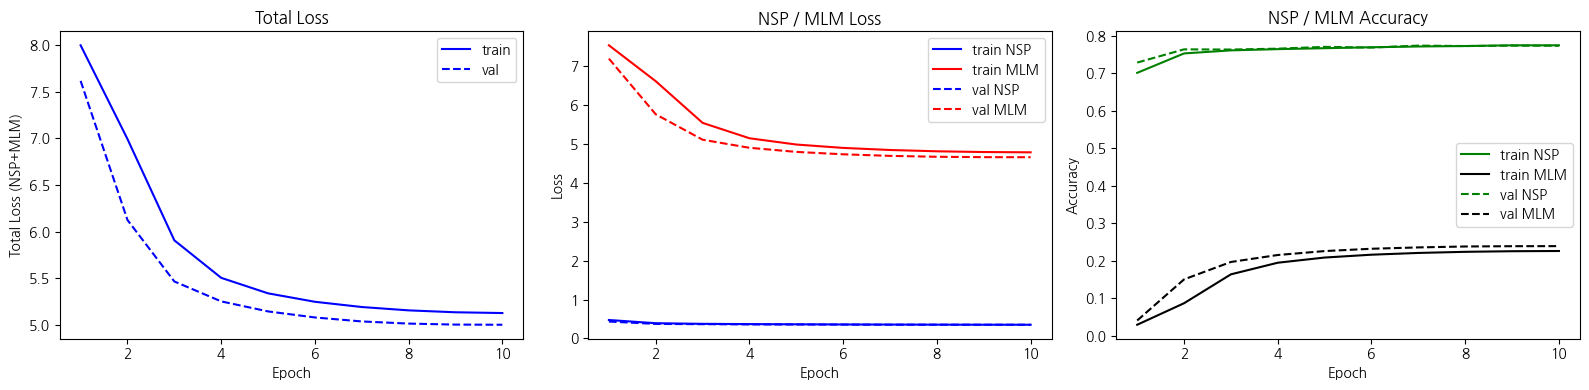

In [13]:
def plot_history(history, title_suffix=""):

    epochs_range = range(1, len(history["train"]) + 1)
    train, val = history["train"], history["val"]

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    # 1) 전체 loss
    axes[0].plot(epochs_range, [m["loss"] for m in train], "b-", label="train")
    axes[0].plot(epochs_range, [m["loss"] for m in val], "b--", label="val")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Total Loss (NSP+MLM)")
    axes[0].set_title(f"Total Loss{title_suffix}"); axes[0].legend()

    # 2) loss breakdown
    axes[1].plot(epochs_range, [m["nsp_loss"] for m in train], "b-", label="train NSP")
    axes[1].plot(epochs_range, [m["mlm_loss"] for m in train], "r-", label="train MLM")
    axes[1].plot(epochs_range, [m["nsp_loss"] for m in val], "b--", label="val NSP")
    axes[1].plot(epochs_range, [m["mlm_loss"] for m in val], "r--", label="val MLM")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")
    axes[1].set_title(f"NSP / MLM Loss{title_suffix}"); axes[1].legend()

    # 3) accuracy
    axes[2].plot(epochs_range, [m["nsp_acc"] for m in train], "g-", label="train NSP")
    axes[2].plot(epochs_range, [m["mlm_acc"] for m in train], "k-", label="train MLM")
    axes[2].plot(epochs_range, [m["nsp_acc"] for m in val], "g--", label="val NSP")
    axes[2].plot(epochs_range, [m["mlm_acc"] for m in val], "k--", label="val MLM")
    axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("Accuracy")
    axes[2].set_title(f"NSP / MLM Accuracy{title_suffix}"); axes[2].legend()

    plt.tight_layout()
    plt.show()

plot_history(history)

## 비교실험


전체 코퍼스로 조합을 다 돌리면 시간이 너무 오래 걸릴 것 같아서, 비교실험은 코퍼스 앞부분만 잘라낸 작은 서브셋과 적은 epoch 수로 빠르게 비교하는 용도로 만들었다.


In [14]:
ABLATION_EPOCHS = 3          # 비교실험용 epoch 수
ABLATION_N_LINES = 200_000   # 비교실험용으로 사용할 코퍼스 줄 수

def prepare_ablation_corpus(config, n_lines=ABLATION_N_LINES):

    ablation_corpus = f"{config['data_dir']}/kowiki_ablation.txt"
    if not os.path.exists(ablation_corpus):
        with open(config["corpus_file"], "r") as fin, open(ablation_corpus, "w") as fout:
            for i, line in enumerate(fin):
                if i >= n_lines:
                    break
                fout.write(line)
    return ablation_corpus

def plot_comparison(histories, metric="loss", title=""):
    """histories: train은 실선, val은 점선"""
    plt.figure(figsize=(7, 4.5))
    colors = plt.cm.tab10.colors
    for i, (label, hist) in enumerate(histories.items()):
        c = colors[i % len(colors)]
        xs = range(1, len(hist["train"]) + 1)
        plt.plot(xs, [m[metric] for m in hist["train"]], color=c, linestyle="-", label=f"{label} (train)")
        plt.plot(xs, [m[metric] for m in hist["val"]], color=c, linestyle="--", label=f"{label} (val)")
    plt.xlabel("Epoch"); plt.ylabel(metric)
    plt.title(title); plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

### 비교 1 : vocab_size 비교

모델 크기는 CONFIG와 동일하게 고정

make_pretrain_data(ablation_vocab4000.json):   0%|          | 0/200000 [00:00<?, ?it/s]

load_pretrain_data(vocab4000):   0%|          | 0/65070 [00:00<?, ?it/s]

[vocab_size=4000] 실제 vocab 크기=4007, 파라미터 수=630,528
[Epoch 1/3] train_loss=7.1628 (nsp=0.6307, mlm=6.5321) | val_loss=6.8038 (nsp=0.6098, mlm=6.1940) | val_nsp_acc=0.580, val_mlm_acc=0.058
[Epoch 2/3] train_loss=6.7928 (nsp=0.6041, mlm=6.1886) | val_loss=6.7812 (nsp=0.6051, mlm=6.1761) | val_nsp_acc=0.579, val_mlm_acc=0.063
[Epoch 3/3] train_loss=6.7694 (nsp=0.5996, mlm=6.1697) | val_loss=6.7681 (nsp=0.6013, mlm=6.1668) | val_nsp_acc=0.581, val_mlm_acc=0.063


make_pretrain_data(ablation_vocab8000.json):   0%|          | 0/200000 [00:00<?, ?it/s]

load_pretrain_data(vocab8000):   0%|          | 0/60690 [00:00<?, ?it/s]

[vocab_size=8000] 실제 vocab 크기=8007, 파라미터 수=1,014,528
[Epoch 1/3] train_loss=8.4467 (nsp=0.6392, mlm=7.8075) | val_loss=8.1852 (nsp=0.6159, mlm=7.5693) | val_nsp_acc=0.580, val_mlm_acc=0.029
[Epoch 2/3] train_loss=8.1612 (nsp=0.6098, mlm=7.5513) | val_loss=8.1549 (nsp=0.5956, mlm=7.5593) | val_nsp_acc=0.600, val_mlm_acc=0.029
[Epoch 3/3] train_loss=8.1422 (nsp=0.6040, mlm=7.5382) | val_loss=8.1510 (nsp=0.5945, mlm=7.5565) | val_nsp_acc=0.603, val_mlm_acc=0.029


make_pretrain_data(ablation_vocab16000.json):   0%|          | 0/200000 [00:00<?, ?it/s]

load_pretrain_data(vocab16000):   0%|          | 0/58182 [00:00<?, ?it/s]

[vocab_size=16000] 실제 vocab 크기=16007, 파라미터 수=1,782,528
[Epoch 1/3] train_loss=9.1458 (nsp=0.6392, mlm=8.5066) | val_loss=8.8332 (nsp=0.6249, mlm=8.2083) | val_nsp_acc=0.583, val_mlm_acc=0.037
[Epoch 2/3] train_loss=8.8182 (nsp=0.6143, mlm=8.2039) | val_loss=8.8108 (nsp=0.6125, mlm=8.1983) | val_nsp_acc=0.587, val_mlm_acc=0.037
[Epoch 3/3] train_loss=8.7905 (nsp=0.6044, mlm=8.1861) | val_loss=8.8051 (nsp=0.6092, mlm=8.1958) | val_nsp_acc=0.589, val_mlm_acc=0.037


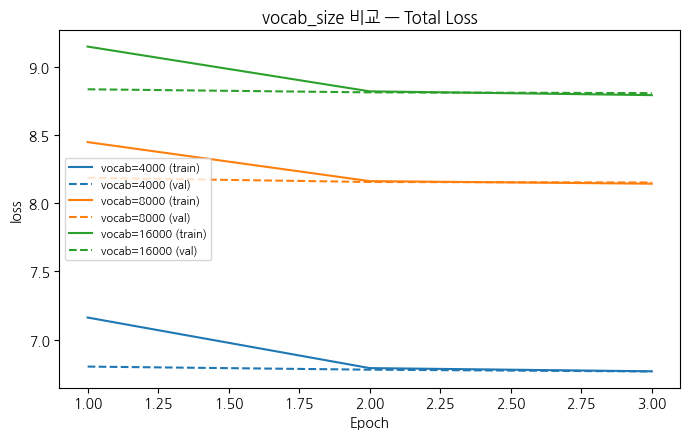

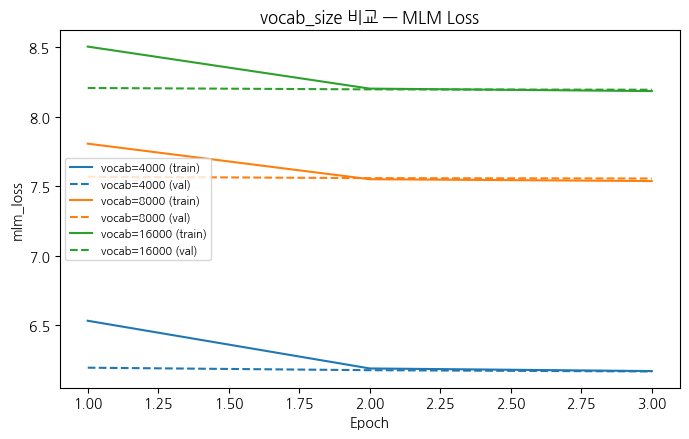

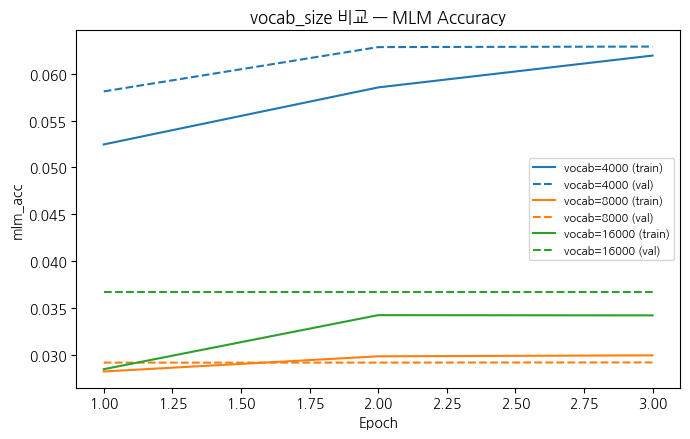

In [15]:
def compare_vocab_size(vocab_sizes=(4000, 8000, 16000), epochs=ABLATION_EPOCHS):
    ablation_corpus = prepare_ablation_corpus(CONFIG)
    histories = {}

    for vs in vocab_sizes:
        tag = f"vocab{vs}"
        prefix = f"{CONFIG['model_dir']}/ablation_{tag}"
        if not os.path.exists(prefix + ".model"):
            train_sentencepiece(ablation_corpus, prefix, vs)
        v, vocab_list = load_vocab(prefix)

        json_path = f"{CONFIG['data_dir']}/ablation_{tag}.json"
        if not os.path.exists(json_path):
            make_pretrain_data(v, vocab_list, ablation_corpus, json_path, CONFIG["n_seq"], CONFIG["mask_prob"])

        train_ds, val_ds = build_train_val_datasets(v, json_path, CONFIG["n_seq"], CONFIG["val_ratio"], tag=tag)

        m = PreTrainModel(build_model_config(v, CONFIG)).to(device)
        print(f"[vocab_size={vs}] 실제 vocab 크기={len(v)}, 파라미터 수={count_parameters(m):,}")

        tl = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True)
        vl = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False)
        exp_cfg = {**CONFIG, "epochs": epochs}
        histories[f"vocab={vs}"] = train_model(m, tl, vl, exp_cfg, verbose=True, checkpoint_tag=tag)

    plot_comparison(histories, metric="loss", title="vocab_size 비교 — Total Loss")
    plot_comparison(histories, metric="mlm_loss", title="vocab_size 비교 — MLM Loss")
    plot_comparison(histories, metric="mlm_acc", title="vocab_size 비교 — MLM Accuracy")
    return histories

vocab_size_histories = compare_vocab_size()

### 비교 2 : 모델 크기 비교


[small] {'d_model': 64, 'n_head': 4, 'd_head': 16, 'd_ff': 256, 'n_layer': 2} → 파라미터 수=625,152 (0.63M)
[Epoch 1/3] train_loss=7.8530 (nsp=0.4541, mlm=7.3989) | val_loss=7.3526 (nsp=0.3859, mlm=6.9667) | val_nsp_acc=0.759, val_mlm_acc=0.057
[Epoch 2/3] train_loss=7.0748 (nsp=0.3827, mlm=6.6921) | val_loss=6.7674 (nsp=0.3691, mlm=6.3984) | val_nsp_acc=0.767, val_mlm_acc=0.113
[Epoch 3/3] train_loss=6.8192 (nsp=0.3736, mlm=6.4456) | val_loss=6.6871 (nsp=0.3679, mlm=6.3192) | val_nsp_acc=0.767, val_mlm_acc=0.119
[base] {'d_model': 96, 'n_head': 4, 'd_head': 24, 'd_ff': 384, 'n_layer': 2} → 파라미터 수=1,014,528 (1.01M)
[Epoch 1/3] train_loss=7.7790 (nsp=0.4503, mlm=7.3287) | val_loss=7.1622 (nsp=0.3904, mlm=6.7718) | val_nsp_acc=0.756, val_mlm_acc=0.074
[Epoch 2/3] train_loss=6.8844 (nsp=0.3831, mlm=6.5013) | val_loss=6.5047 (nsp=0.3701, mlm=6.1346) | val_nsp_acc=0.765, val_mlm_acc=0.131
[Epoch 3/3] train_loss=6.5593 (nsp=0.3729, mlm=6.1864) | val_loss=6.3700 (nsp=0.3680, mlm=6.0020) | val_nsp_

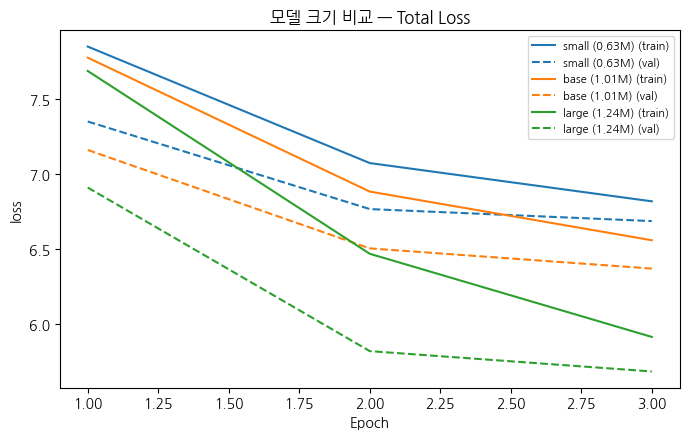

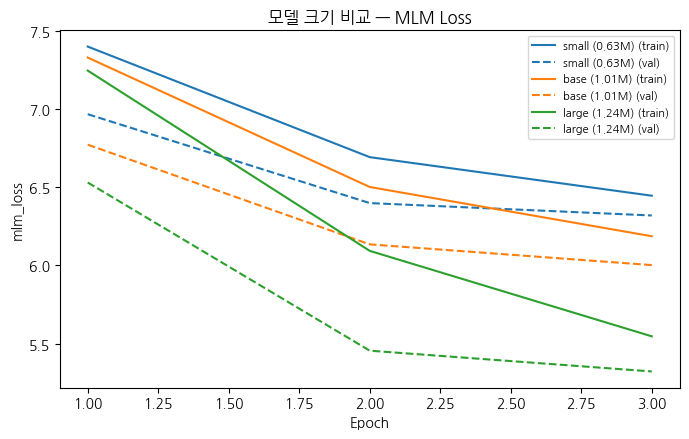

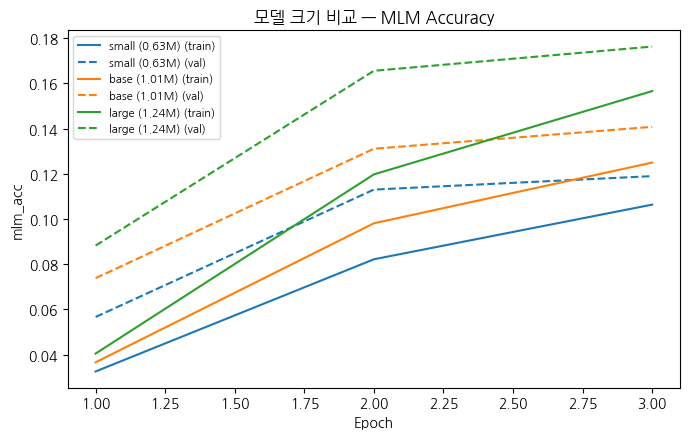

In [16]:
def compare_model_size(size_configs=None, epochs=ABLATION_EPOCHS):
    if size_configs is None:
        size_configs = {
            "small":  dict(d_model=64, n_head=4, d_head=16, d_ff=256, n_layer=2),
            "base":   dict(d_model=96, n_head=4, d_head=24, d_ff=384, n_layer=2),
            "large":  dict(d_model=96, n_head=4, d_head=24, d_ff=384, n_layer=4),
        }

    histories = {}
    for label, overrides in size_configs.items():
        model_cfg = {**CONFIG, **overrides}
        m = PreTrainModel(build_model_config(vocab, model_cfg)).to(device)
        n_params = count_parameters(m)
        print(f"[{label}] {overrides} → 파라미터 수={n_params:,} ({n_params/1e6:.2f}M)")

        tl = DataLoader(train_dataset, batch_size=CONFIG["batch_size"], shuffle=True)
        vl = DataLoader(val_dataset, batch_size=CONFIG["batch_size"], shuffle=False)
        exp_cfg = {**CONFIG, **overrides, "epochs": epochs}
        histories[f"{label} ({n_params/1e6:.2f}M)"] = train_model(m, tl, vl, exp_cfg, verbose=True, checkpoint_tag=f"size_{label}")

    plot_comparison(histories, metric="loss", title="모델 크기 비교 — Total Loss")
    plot_comparison(histories, metric="mlm_loss", title="모델 크기 비교 — MLM Loss")
    plot_comparison(histories, metric="mlm_acc", title="모델 크기 비교 — MLM Accuracy")
    return histories

model_size_histories = compare_model_size()

### 비교 3 : mask_prob 비교

tokenizer는 CONFIG와 동일하게 고정해두고 `mask_prob`만 바꿔서 pretrain 데이터를 다시 만든 다음 비교했다.

make_pretrain_data(ablation_mask10.json):   0%|          | 0/200000 [00:00<?, ?it/s]

load_pretrain_data(mask10):   0%|          | 0/61206 [00:00<?, ?it/s]

[Epoch 1/3] train_loss=8.3410 (nsp=0.6380, mlm=7.7030) | val_loss=8.0439 (nsp=0.6192, mlm=7.4247) | val_nsp_acc=0.582, val_mlm_acc=0.028
[Epoch 2/3] train_loss=8.0220 (nsp=0.6107, mlm=7.4114) | val_loss=8.0192 (nsp=0.6026, mlm=7.4166) | val_nsp_acc=0.586, val_mlm_acc=0.028
[Epoch 3/3] train_loss=8.0016 (nsp=0.6033, mlm=7.3984) | val_loss=8.0151 (nsp=0.6007, mlm=7.4144) | val_nsp_acc=0.586, val_mlm_acc=0.028


make_pretrain_data(ablation_mask15.json):   0%|          | 0/200000 [00:00<?, ?it/s]

load_pretrain_data(mask15):   0%|          | 0/61206 [00:00<?, ?it/s]

[Epoch 1/3] train_loss=8.3272 (nsp=0.6384, mlm=7.6889) | val_loss=8.0223 (nsp=0.6154, mlm=7.4069) | val_nsp_acc=0.591, val_mlm_acc=0.028
[Epoch 2/3] train_loss=8.0157 (nsp=0.6122, mlm=7.4034) | val_loss=8.0062 (nsp=0.6096, mlm=7.3966) | val_nsp_acc=0.585, val_mlm_acc=0.028
[Epoch 3/3] train_loss=7.9965 (nsp=0.6057, mlm=7.3908) | val_loss=7.9923 (nsp=0.6003, mlm=7.3920) | val_nsp_acc=0.599, val_mlm_acc=0.028


make_pretrain_data(ablation_mask20.json):   0%|          | 0/200000 [00:00<?, ?it/s]

load_pretrain_data(mask20):   0%|          | 0/61206 [00:00<?, ?it/s]

[Epoch 1/3] train_loss=8.3180 (nsp=0.6370, mlm=7.6811) | val_loss=8.0194 (nsp=0.6164, mlm=7.4030) | val_nsp_acc=0.575, val_mlm_acc=0.028
[Epoch 2/3] train_loss=8.0097 (nsp=0.6090, mlm=7.4007) | val_loss=7.9971 (nsp=0.6035, mlm=7.3935) | val_nsp_acc=0.593, val_mlm_acc=0.028
[Epoch 3/3] train_loss=7.9928 (nsp=0.6030, mlm=7.3898) | val_loss=7.9909 (nsp=0.6013, mlm=7.3896) | val_nsp_acc=0.581, val_mlm_acc=0.028


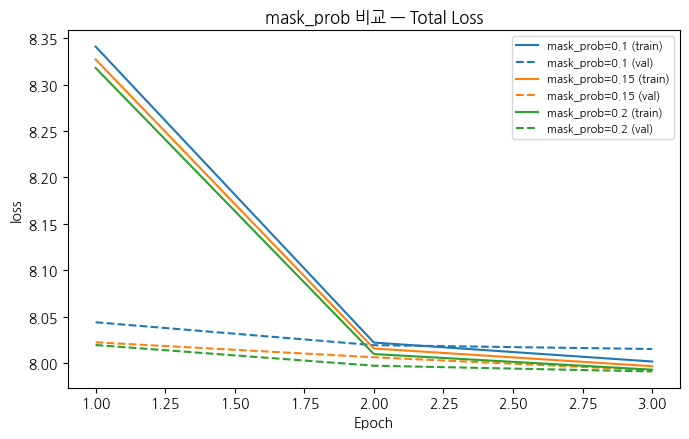

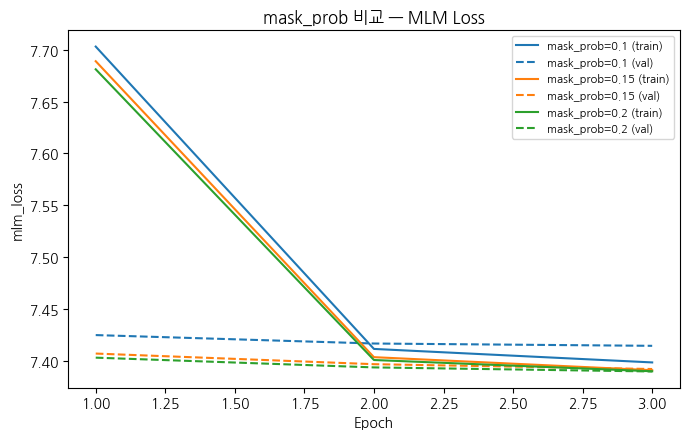

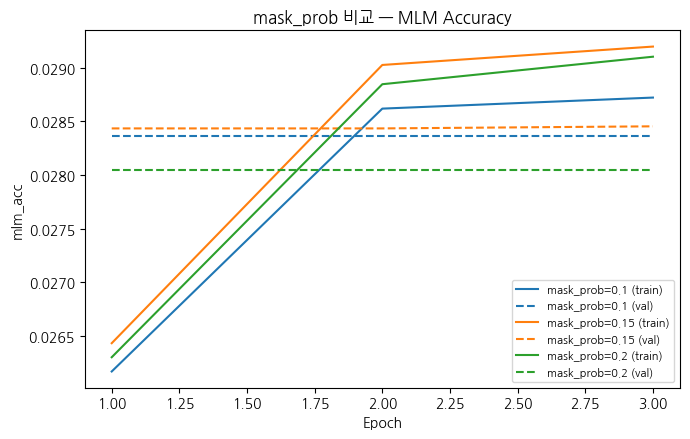

In [17]:
def compare_mask_prob(mask_probs=(0.10, 0.15, 0.20), epochs=ABLATION_EPOCHS):
    ablation_corpus = prepare_ablation_corpus(CONFIG)
    histories = {}

    for mp in mask_probs:
        tag = f"mask{int(mp * 100)}"
        json_path = f"{CONFIG['data_dir']}/ablation_{tag}.json"
        if not os.path.exists(json_path):
            make_pretrain_data(vocab, VOCAB_LIST, ablation_corpus, json_path, CONFIG["n_seq"], mp)

        train_ds, val_ds = build_train_val_datasets(vocab, json_path, CONFIG["n_seq"], CONFIG["val_ratio"], tag=tag)

        m = PreTrainModel(build_model_config(vocab, CONFIG)).to(device)
        tl = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True)
        vl = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False)
        exp_cfg = {**CONFIG, "epochs": epochs, "mask_prob": mp}
        histories[f"mask_prob={mp}"] = train_model(m, tl, vl, exp_cfg, verbose=True, checkpoint_tag=tag)

    plot_comparison(histories, metric="loss", title="mask_prob 비교 — Total Loss")
    plot_comparison(histories, metric="mlm_loss", title="mask_prob 비교 — MLM Loss")
    plot_comparison(histories, metric="mlm_acc", title="mask_prob 비교 — MLM Accuracy")
    return histories

mask_prob_histories = compare_mask_prob()

## 결론

### 데이터 / 모델 규모

| 항목 | 값 |
|---|---|
| vocab_size | 8000 (+특수문자 7개 = 8007) |
| train / val instance 수 | 872,265 / 45,908 |
| 모델 파라미터 수 | 1,014,528 (1.01M) |

### 메인 학습 결과 (10 epoch, 전체 데이터)

| 지표 | 1 epoch | 10 epoch |
|---|---|---|
| train loss | 7.9967 | 5.1290 |
| val loss | 7.6156 | 5.0036 |
| NSP loss (val) | 0.4350 | 0.3524 |
| NSP accuracy (val) | 0.729 | 0.774 |
| MLM loss (val) | 7.1805 | 4.6512 |
| MLM accuracy (val) | 0.041 | 0.239 |

- epoch 7~10 구간에서 감소폭이 줄며 수렴하는 모습을 보였다.
- val_loss가 train_loss보다 낮은 건 train 때만 dropout이 켜지기 때문에 생기는 정상적인 차이다.
- MLM accuracy 24%는 vocab 8000개(무작위 추측 시 0.0125%) 대비 mini 모델치고 의미 있는 수준이라고 보았다.

### 비교실험 결과 (3 epoch 기준)

| 실험 | 조건 | 파라미터 수 | val loss (최종) | 비고 |
|---|---|---|---|---|
| vocab_size | 4000 | 630K | 6.77 | vocab이 작을수록 짧은 학습에서 더 빨리 내려감 |
| vocab_size | 8000 | 1.01M | 8.15 | |
| vocab_size | 16000 | 1.78M | 8.81 |  |
| 모델 크기 | small (2layer) | 0.63M | 6.69 | 용량이 클수록 같은 epoch 안에서 더 빨리 학습 |
| 모델 크기 | base (2layer) | 1.01M | 6.37 | |
| 모델 크기 | large (4layer) | 1.24M | 5.68 | |
| mask_prob | 0.10 / 0.15 / 0.20 | 동일 | 7.99~8.02 (동일) | 이 scale(서브셋+3epoch)에서는 뚜렷한 차이 없음 |

> 데이터 전처리부터 모델 구현, 10 epoch 학습까지 파이프라인이 의도한 대로 동작했고, MLM/NSP loss의 안정적인 감소를 확인했다. MLM accuracy가 24% 정도에 머문 건 mini 모델 크기의 한계이며, 모델 크기 비교실험에서 레이어를 늘리면 개선될 것 같다.

## 회고
하루 결석을 해서 시간상 학습만 수행하고 성능을 높이지는 못했지만, 학습자체는 제대로 잘 된 것 같아서 이정도로 만족했다.ㅎ 또한 flow를 작성할때 ai의 도움을 받았는데 깔끔하게 잘 해주는게 너무 편하고 좋다는 생각이 든다.